In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("data/server_data_complete.csv")


print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())


print("\nMissing values in each column:")
print(df.isnull().sum())


print("\nTarget distribution (will_fail_24h):")
print(df["will_fail_24h"].value_counts())

print("\nTarget distribution in percentage:")
print(df["will_fail_24h"].value_counts(normalize=True) * 100)

First 5 rows:
                    timestamp           server_id  client_id  data_center_id  \
0  2026-06-05 13:05:50.205339  CL01_DC001_SRV0001          1               1   
1  2026-06-05 13:10:50.205339  CL01_DC001_SRV0001          1               1   
2  2026-06-05 13:15:50.205339  CL01_DC001_SRV0001          1               1   
3  2026-06-05 13:20:50.205339  CL01_DC001_SRV0001          1               1   
4  2026-06-05 13:25:50.205339  CL01_DC001_SRV0001          1               1   

   memory_usage_pct  disk_io_mbps  network_latency_ms  error_count  \
0             69.87        108.39               16.13          1.0   
1             67.21        128.37               12.44          1.0   
2               NaN        103.11                9.01          3.0   
3             77.17           NaN                 NaN          1.0   
4               NaN        117.91               12.39          1.0   

   crash_count  days_since_maintenance  is_business_hours  is_weekend  \
0          

In [ ]:

monitor_cols = [
    "memory_usage_pct",
    "disk_io_mbps",
    "network_latency_ms",
    "error_count",
    "crash_count"
]


for col in monitor_cols:
    df[col + "_missing"] = df[col].isnull().astype(int)


df[monitor_cols] = (
    df.groupby("server_id")[monitor_cols]
      .transform(lambda x: x.ffill().bfill())
)


for col in monitor_cols:
    df[col] = df[col].fillna(df[col].median())


print("Missing values after imputation:\n")
print(df[monitor_cols].isnull().sum())

print("\nSample rows after filling:")
print(df.head())

Missing values after imputation:

memory_usage_pct      0
disk_io_mbps          0
network_latency_ms    0
error_count           0
crash_count           0
dtype: int64

Sample rows after filling:
                    timestamp           server_id  client_id  data_center_id  \
0  2026-06-05 13:05:50.205339  CL01_DC001_SRV0001          1               1   
1  2026-06-05 13:10:50.205339  CL01_DC001_SRV0001          1               1   
2  2026-06-05 13:15:50.205339  CL01_DC001_SRV0001          1               1   
3  2026-06-05 13:20:50.205339  CL01_DC001_SRV0001          1               1   
4  2026-06-05 13:25:50.205339  CL01_DC001_SRV0001          1               1   

   memory_usage_pct  disk_io_mbps  network_latency_ms  error_count  \
0             69.87        108.39               16.13          1.0   
1             67.21        128.37               12.44          1.0   
2             67.21        103.11                9.01          3.0   
3             77.17        103.11           

In [ ]:


# Make sure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Check if conversion worked
print(df["timestamp"].dtype)

# ----- A. Time-based features -----
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek   # Monday=0, Sunday=6

# ----- B. Rolling features per server -----
df["mem_avg_3"] = (
    df.groupby("server_id")["memory_usage_pct"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["disk_avg_3"] = (
    df.groupby("server_id")["disk_io_mbps"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["latency_avg_3"] = (
    df.groupby("server_id")["network_latency_ms"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["error_sum_3"] = (
    df.groupby("server_id")["error_count"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).sum())
)

df["crash_sum_3"] = (
    df.groupby("server_id")["crash_count"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).sum())
)

# ----- C. Trend / difference features -----
df["mem_diff"] = df.groupby("server_id")["memory_usage_pct"].diff().fillna(0)
df["disk_diff"] = df.groupby("server_id")["disk_io_mbps"].diff().fillna(0)
df["latency_diff"] = df.groupby("server_id")["network_latency_ms"].diff().fillna(0)

# ----- Preview engineered features -----
new_cols = [
    "hour", "day_of_week",
    "mem_avg_3", "disk_avg_3", "latency_avg_3",
    "error_sum_3", "crash_sum_3",
    "mem_diff", "disk_diff", "latency_diff"
]

print("\nEngineered feature sample:")
print(df[new_cols].head(10))

datetime64[ns]

Engineered feature sample:
   hour  day_of_week  mem_avg_3  disk_avg_3  latency_avg_3  error_sum_3  \
0    13            4  69.870000  108.390000      16.130000          1.0   
1    13            4  68.540000  118.380000      14.285000          2.0   
2    13            4  68.096667  113.290000      12.526667          5.0   
3    13            4  70.530000  111.530000      10.153333          5.0   
4    13            4  73.850000  108.043333      10.136667          5.0   
5    13            4  73.860000  121.733333      11.263333          3.0   
6    13            4  71.463333  123.753333      11.723333          3.0   
7    13            4  69.066667  120.676667      13.060000          3.0   
8    13            4  68.750000  103.850000      14.433333          3.0   
9    13            4  67.520000   97.760000      16.023333          3.0   

   crash_sum_3  mem_diff  disk_diff  latency_diff  
0          0.0      0.00       0.00          0.00  
1          0.0     -2.66   

In [6]:
# =========================
# STEP 5: Create X and y
# =========================

feature_cols = [
    # original features
    "client_id",
    "data_center_id",
    "memory_usage_pct",
    "disk_io_mbps",
    "network_latency_ms",
    "error_count",
    "crash_count",
    "days_since_maintenance",
    "is_business_hours",
    "is_weekend",

    # missing indicators
    "memory_usage_pct_missing",
    "disk_io_mbps_missing",
    "network_latency_ms_missing",
    "error_count_missing",
    "crash_count_missing",

    # engineered time / rolling / trend features
    "hour",
    "day_of_week",
    "mem_avg_3",
    "disk_avg_3",
    "latency_avg_3",
    "error_sum_3",
    "crash_sum_3",
    "mem_diff",
    "disk_diff",
    "latency_diff"
]

# Create feature matrix X and target y
X = df[feature_cols]
y = df["will_fail_24h"]

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(feature_cols)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (12970141, 25)
y shape: (12970141,)

Feature columns:
['client_id', 'data_center_id', 'memory_usage_pct', 'disk_io_mbps', 'network_latency_ms', 'error_count', 'crash_count', 'days_since_maintenance', 'is_business_hours', 'is_weekend', 'memory_usage_pct_missing', 'disk_io_mbps_missing', 'network_latency_ms_missing', 'error_count_missing', 'crash_count_missing', 'hour', 'day_of_week', 'mem_avg_3', 'disk_avg_3', 'latency_avg_3', 'error_sum_3', 'crash_sum_3', 'mem_diff', 'disk_diff', 'latency_diff']

Target distribution:
will_fail_24h
0    12399137
1      571004
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

# =========================
# STEP 6: Create sampled dataset for modeling
# =========================

# Combine X and y temporarily
model_df = X.copy()
model_df["will_fail_24h"] = y

# Take stratified sample of 1,000,000 rows
sample_df = model_df.groupby("will_fail_24h", group_keys=False).apply(
    lambda x: x.sample(frac=1000000 / len(model_df), random_state=42)
)

# Separate X and y again
X_sample = sample_df.drop(columns=["will_fail_24h"])
y_sample = sample_df["will_fail_24h"]

print("Sampled dataset shape:", sample_df.shape)
print("\nSample target distribution:")
print(y_sample.value_counts(normalize=True) * 100)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

C:\Users\ricky\AppData\Local\Temp\ipykernel_15988\3566953439.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = model_df.groupby("will_fail_24h", group_keys=False).apply(


Sampled dataset shape: (1000000, 26)

Sample target distribution:
will_fail_24h
0    95.5975
1     4.4025
Name: proportion, dtype: float64

Train shape: (800000, 25) (800000,)
Test shape: (200000, 25) (200000,)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =========================
# STEP 7: Train Logistic Regression
# =========================

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train the model
log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Evaluation
print("=== Logistic Regression Results ===\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

C:\Users\ricky\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression Results ===

Confusion Matrix:
[[187136   4059]
 [    96   8709]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    191195
           1       0.68      0.99      0.81      8805

    accuracy                           0.98    200000
   macro avg       0.84      0.98      0.90    200000
weighted avg       0.99      0.98      0.98    200000


ROC-AUC Score:
0.9951547604467843


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =========================
# STEP 8: Train Random Forest
# =========================

rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    max_depth=12,           # keep it controlled so training is manageable
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Random Forest Results ===\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_rf))

=== Random Forest Results ===

Confusion Matrix:
[[189379   1816]
 [   157   8648]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    191195
           1       0.83      0.98      0.90      8805

    accuracy                           0.99    200000
   macro avg       0.91      0.99      0.95    200000
weighted avg       0.99      0.99      0.99    200000


ROC-AUC Score:
0.9972348111111264


In [12]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision_class_1": [0.68, 0.83],
    "Recall_class_1": [0.99, 0.98],
    "F1_class_1": [0.81, 0.90],
    "ROC_AUC": [0.9951547604467843, 0.9972348111111264]
})

print(comparison_df)

                 Model  Precision_class_1  Recall_class_1  F1_class_1  \
0  Logistic Regression               0.68            0.99        0.81   
1        Random Forest               0.83            0.98        0.90   

    ROC_AUC  
0  0.995155  
1  0.997235  


In [13]:
# =========================
# STEP 10: Feature Importance from Random Forest
# =========================

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)

print("Top 15 Important Features:\n")
print(feature_importance.head(15))

Top 15 Important Features:

                     Feature  Importance
0           memory_usage_pct    0.546279
1                  mem_avg_3    0.268937
2                error_sum_3    0.049817
3                crash_sum_3    0.042019
4                error_count    0.029402
5                   mem_diff    0.021724
6                crash_count    0.018457
7     days_since_maintenance    0.010875
8   memory_usage_pct_missing    0.003745
9             data_center_id    0.001106
10                disk_avg_3    0.000951
11        network_latency_ms    0.000941
12             latency_avg_3    0.000934
13              disk_io_mbps    0.000786
14              latency_diff    0.000759


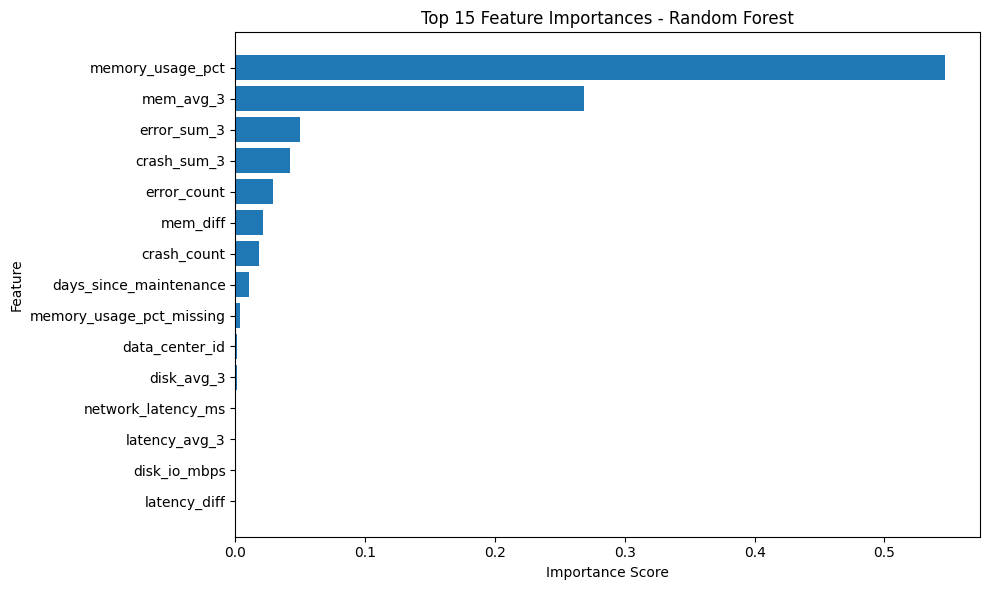

In [14]:
import matplotlib.pyplot as plt

# Select top 15 important features
top_n = 15
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =========================
# STEP 12: Client-wise split
# =========================

# Check which clients are present in sampled data
print("Clients in sample_df:", sorted(sample_df["client_id"].unique()))

# Train on clients 1-8, test on clients 9-10
train_clients = [1, 2, 3, 4, 5, 6, 7, 8]
test_clients = [9, 10]

train_client_df = sample_df[sample_df["client_id"].isin(train_clients)].copy()
test_client_df = sample_df[sample_df["client_id"].isin(test_clients)].copy()

print("Train client dataset shape:", train_client_df.shape)
print("Test client dataset shape:", test_client_df.shape)

# Create X and y
X_train_client = train_client_df[feature_cols]
y_train_client = train_client_df["will_fail_24h"]

X_test_client = test_client_df[feature_cols]
y_test_client = test_client_df["will_fail_24h"]

print("\nTrain target distribution:")
print(y_train_client.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test_client.value_counts(normalize=True) * 100)

# =========================
# Train Random Forest again
# =========================
rf_client_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_client_model.fit(X_train_client, y_train_client)

# Predictions
y_pred_client = rf_client_model.predict(X_test_client)
y_prob_client = rf_client_model.predict_proba(X_test_client)[:, 1]

# Evaluation
print("\n=== Client-wise Random Forest Results ===\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test_client, y_pred_client))

print("\nClassification Report:")
print(classification_report(y_test_client, y_pred_client))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_client, y_prob_client))

Clients in sample_df: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Train client dataset shape: (702634, 26)
Test client dataset shape: (297366, 26)

Train target distribution:
will_fail_24h
0    95.939138
1     4.060862
Name: proportion, dtype: float64

Test target distribution:
will_fail_24h
0    94.790258
1     5.209742
Name: proportion, dtype: float64

=== Client-wise Random Forest Results ===

Confusion Matrix:
[[278839   3035]
 [   260  15232]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    281874
           1       0.83      0.98      0.90     15492

    accuracy                           0.99    297366
   macro avg       0.92      0.99      0.95    297366
weighted avg       0.99      0.99      0.99    297366


ROC-AUC Score:
0.9965844349873603


In [16]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "rf_model.pkl")

# Save feature column list
joblib.dump(feature_cols, "feature_columns.pkl")

print("Model and feature columns saved successfully.")

Model and feature columns saved successfully.


In [17]:
import joblib

joblib.dump(rf_client_model, "rf_model.pkl")
joblib.dump(feature_cols, "feature_columns.pkl")

print("Client-wise Random Forest model saved successfully.")

Client-wise Random Forest model saved successfully.


In [18]:
sample_app_df = df.sample(10000, random_state=42)
sample_app_df.to_csv("sample_input.csv", index=False)

In [19]:
import joblib

joblib.dump(random_forest, "random_forest_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Saved successfully!")

NameError: name 'random_forest' is not defined